In [16]:
import sys
import argparse
import os


from selector.config_selector import _CONFIGS
from utils.logger import Logger    
from run.sde import VESDE
from model.optimizer import AdamOptimizer
from model.ncsnpp import NCSNpp
from config.ve.cifar10_ncsnpp_cont import HFMRIContConfig
from model.predictors import ReverseDiffusionPredictor
from model.correctors import NoneCorrector
import torch
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from run.sample import Sampler
from inr import INR
from degrade import DegradationModel
from hqs import DiffDeuR
from lf_handlers import get_lf_mri_dataloader
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
from main import get_sampler
device = "cuda"
print(_CONFIGS.keys())
%matplotlib inline

dict_keys(['hfmri_ncsnpp_cont'])


In [2]:
sampler = get_sampler("hfmri_ncsnpp_cont")
# inr = INR(num_levels=12, max_entries=2**23, feature_dims=2, coarsest_res=2, finest_res=256)
# degradation_model = DegradationModel(blur_sigma=1.5, downsample_factor=2, noise_std=0.05)

2025-07-06 00:35:21,379 - runner - INFO - Loading checkpoint from assets/ve/hfmri_ncsnpp_cont/ckpt/epoch_5.pth


In [3]:
# Initialize Dataloader
dataloader = get_lf_mri_dataloader()

# Test one batch
for y in dataloader:
    print(f"LF MRI shape: {y.shape}")  # Should be [1, 1, 128, 128]
    print(y.min(), y.max())
    break

LF MRI shape: torch.Size([1, 1, 256, 256])
tensor(-1.) tensor(1.)


In [35]:
def guided_score_projection(score_model, lf_image, sde, steps=300, epsilon=0.0005, lambda_dc=0.01):
    device = lf_image.device
    score_model = score_model.to(device).eval()

    # Initialize x from noisy LF image
    t0 = torch.tensor([0.9], device=device)
    sigma0 = sde.get_sigma(t0.to(device))[1].view(-1, 1, 1, 1)
    x = lf_image + sigma0 * torch.randn_like(lf_image)

    t_schedule = torch.linspace(0.9, 0.1, steps, device=device)

    for step in range(steps):
        t = t_schedule[step].unsqueeze(0)
        with torch.no_grad():
            sigma = sde.get_sigma(t)[1].view(-1, 1, 1, 1)
            noise = torch.randn_like(x)
            xt = x + sigma * noise

            score = score_model(xt, t)

            x = x + epsilon * score
            x = (1 - lambda_dc) * x + lambda_dc * lf_image
            x = x.clamp(-1.0, 1.0)

        if step % 25 == 0 or step == steps - 1:
            print(f"[Step {step}] Mean x: {x.mean().item():.4f}, Score norm: {score.norm().item():.2f}")

    return x.detach()


In [10]:
lf_image=next(iter(dataloader))
lf_image.shape

torch.Size([1, 1, 256, 256])

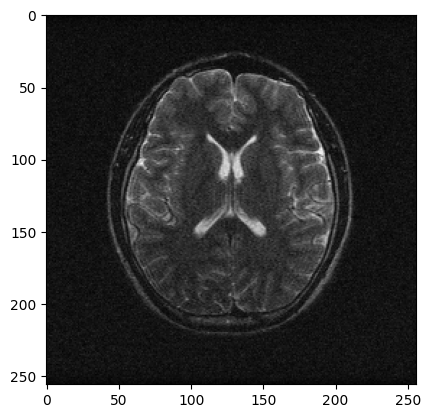

In [11]:
plt.imshow(lf_image[0,0].cpu().numpy(), cmap="gray")

In [36]:
result = guided_score_projection(score_model=sampler.model, lf_image=lf_image.to("cuda"), sde=sampler.sde)

[Step 0] Mean x: -0.0243, Score norm: 284.46
[Step 25] Mean x: -0.1804, Score norm: 307.25
[Step 50] Mean x: -0.3018, Score norm: 334.61
[Step 75] Mean x: -0.3961, Score norm: 367.44
[Step 100] Mean x: -0.4694, Score norm: 406.89
[Step 125] Mean x: -0.5262, Score norm: 455.10
[Step 150] Mean x: -0.5703, Score norm: 513.64
[Step 175] Mean x: -0.6045, Score norm: 585.48
[Step 200] Mean x: -0.6310, Score norm: 676.46
[Step 225] Mean x: -0.6513, Score norm: 801.75
[Step 250] Mean x: -0.6669, Score norm: 993.59
[Step 275] Mean x: -0.6786, Score norm: 1325.20
[Step 299] Mean x: -0.6863, Score norm: 2015.28


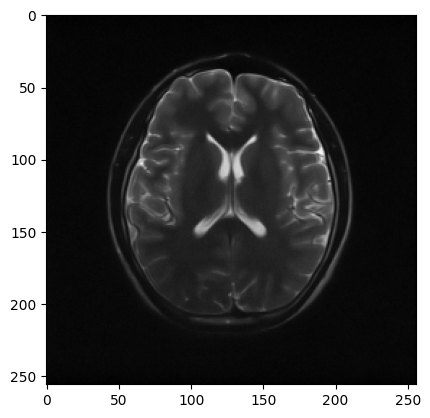

In [37]:
plt.imshow(result[0,0].detach().cpu().numpy(), cmap="gray")